# The Cost of Change: 
### Tracking Treatment Duration Through a 2025 Facility Reorganization

##### This analysis will explore how a organizational re-structuring in August 2025 affected the length of stay at a Substance Use Treatment facility in Minnesota. 

Sections:
1. Data Cleaning & Preparation
2. Categorical Exploration
3. Permutation Testing

## Data Cleaning & Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
los = pd.read_excel("Length of Stay Data.xlsx")

### 1. Convert columns and standardize strings
   - Columns in the Length of Stay Data excel spreadsheet:

     - **Subject_ID:** Each client was pre-assigned a number 1-307
  
     - **Program:** Contains the string "Womens Residental Treatment" on every entry (will be dropped)
  
     - **Admission_Date:** the date the treatment episode started
  
     - **Date_of_Discharge:** the date the treatment episode ended
  
     - **Reason_for_Discharge:** includes the reason the client exited the program

In [3]:
# column conversion
los['Subject_ID'] = pd.to_numeric(los['Subject_ID'], errors='coerce')
los =  los.drop('Program', axis=1)
los['Admission_Date'] = pd.to_datetime(los['Admission_Date'], errors='coerce')
los['Date_of_Discharge'] = pd.to_datetime(los['Date_of_Discharge'], errors='coerce')
los['Reason_for_Discharge'] = los['Reason_for_Discharge'].astype('str')

# standardize strings
string_col = los.select_dtypes(include=['string'])
column_list = string_col.columns.to_list()
los[column_list] = los[column_list].apply(lambda x: x.str.lower())

### 2. Apply Filters
   
   - **Date_of_Discharge** is filtered to include clients who discharged after March 1st 2025 and before end of February 2026 
  
   - **Reason_for_Discharge** includes the discharge types relevant for analysis:
       * *Completed Program*   -  the client has completed all program requirements
       * *Patient left without staff approval*     -   the client chooses to leave the program
       * *Patient conduct (behavioral)*   -   the client has created an unsafe environment for others in the program

In [4]:
#filter discharge date
discharged_filter = los['Date_of_Discharge'].between('2025-03-01', '2026-02-28')
los = los[discharged_filter]
#print(los['Date_of_Discharge'].min(), los['Date_of_Discharge'].max())

# filter discharge reason
target_strings = ['completed program', 'patient left without staff approval', 'patient conduct (behavioral)']
los = los[los['Reason_for_Discharge'].isin(target_strings)]
los['Reason_for_Discharge'].value_counts()

los.head(5)

,Subject_ID,Admission_Date,Date_of_Discharge,Reason_for_Discharge
1,2,2025-03-24,2025-04-14,patient conduct (behavioral)
2,3,2025-06-16,2025-06-18,patient left without staff approval
3,3,2025-08-08,2025-08-13,patient conduct (behavioral)
6,6,2026-02-04,2026-02-05,patient left without staff approval
7,7,2025-04-07,2025-06-05,completed program


### 3. Create Columns
 - **Length_of_Stay:** the date of discharge is subtracted from the date of admission for each treatment episode and one is added to the result. This is done in the residential treatment setting as the client receives services the day they arrive on site.
  
 - **Period:** if the discharge date occurs before August 31st, it is put into the *before re-org* category. The *after re-org* category represents treatment episodes that ended after the re-organization.
  
 - **Discharge_Cat:** assigned based on discharge type
   - *successful* - episodes that resulted in program completion
   - *unsucessful* - episodes that ended with the patient leaving against staff advice or due to patient conduct

In [5]:
# create length of stay column
los['Length_of_Stay'] = (los['Date_of_Discharge'] - los['Admission_Date']).dt.days + 1

#create before and after period categories
los['Period'] = los['Date_of_Discharge'].apply(lambda x: 'before re-org' if x < pd.to_datetime('2025-08-31') else 'after re-org')
los['Period'] = los['Period'].astype('category')
print(los['Period'].value_counts())
print("")

#create discharge type categories (successful vs unsuccessful)
def discharge_type(reason):
    if reason == 'completed program':
        return 'successful'
    else:
        return 'unsuccessful'
    
los['Discharge_Cat'] = los['Reason_for_Discharge'].apply(discharge_type)
los['Discharge_Cat'] = los['Discharge_Cat'].astype('category')
print(los['Discharge_Cat'].value_counts())
los.head(5)

Period
after re-org     140
before re-org    103
Name: count, dtype: int64

Discharge_Cat
unsuccessful    173
successful       70
Name: count, dtype: int64


,Subject_ID,Admission_Date,Date_of_Discharge,Reason_for_Discharge,Length_of_Stay,Period,Discharge_Cat
1,2,2025-03-24,2025-04-14,patient conduct (behavioral),22,before re-org,unsuccessful
2,3,2025-06-16,2025-06-18,patient left without staff approval,3,before re-org,unsuccessful
3,3,2025-08-08,2025-08-13,patient conduct (behavioral),6,before re-org,unsuccessful
6,6,2026-02-04,2026-02-05,patient left without staff approval,2,after re-org,unsuccessful
7,7,2025-04-07,2025-06-05,completed program,60,before re-org,successful


# Exploring Categorical Variables

### 1. Period Breakdown
Comparison of the 6 month period before the re-organziation (*before re-org*) verses the 6 month period after the re-organization (*after re-org*). 

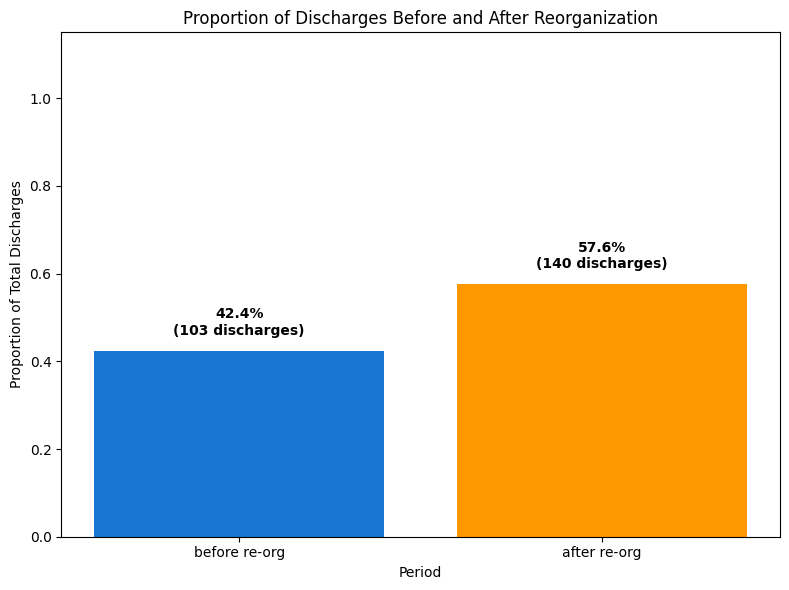

In [6]:
# proportion bar chart for before vs after discharges
period_counts = los['Period'].value_counts(normalize=True).reindex(['before re-org', 'after re-org']).fillna(0)
period_counts_n = los['Period'].value_counts().reindex(['before re-org', 'after re-org']).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(period_counts.index, period_counts.values, color=['#1976D2', '#FF9800'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Proportion of Total Discharges')
ax.set_xlabel('Period')
ax.set_title('Proportion of Discharges Before and After Reorganization')

for i, (prop, count) in enumerate(zip(period_counts.values, period_counts_n.values)):
    ax.text(i, prop + 0.03, f'{prop:.1%}\n({count} discharges)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

The period after the re-organization had a greater proportion of discharges compared to the period before the re-organization. These results were expected as staff and program leadership have noticed an increase in discharge rates in the months following the re-organization. 

Now, let's compare the proportion of successful and unsuccessful discharges between the two periods:

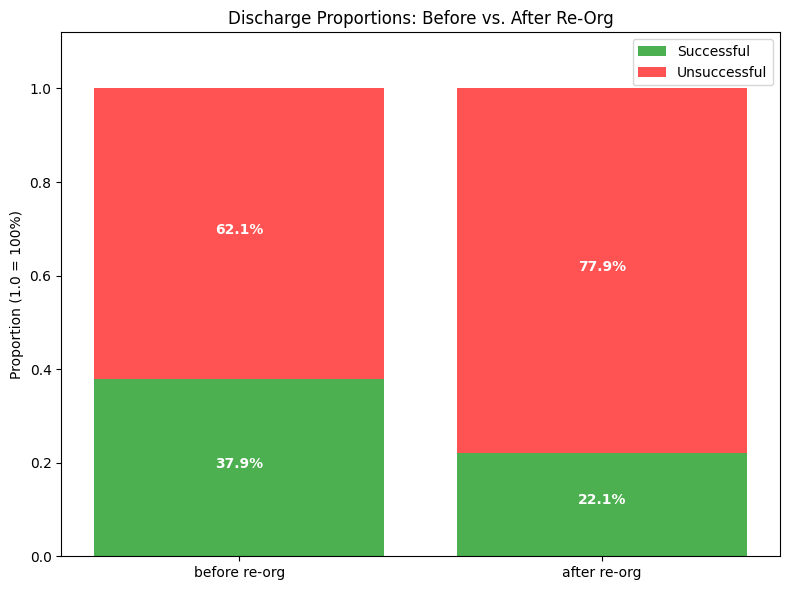

In [7]:
#successful vs unsuccessful

# calculate porportions of successful vs unsuccessful discharges for both periods
before_props = los[los['Period'] == 'before re-org']['Discharge_Cat'].value_counts(normalize=True)
after_props = los[los['Period'] == 'after re-org']['Discharge_Cat'].value_counts(normalize=True)

# prepare data for plot
periods = ['before re-org', 'after re-org']
success_vals = [before_props.get('successful', 0), after_props.get('successful', 0)]
unsuccess_vals = [before_props.get('unsuccessful', 0), after_props.get('unsuccessful', 0)]

# create plot
fig, ax = plt.subplots(figsize=(8, 6))

# plot successes
ax.bar(periods, success_vals, label='Successful', color='#4CAF50')

# plot unsuccessful discharges on top of successes
ax.bar(periods, unsuccess_vals, bottom=success_vals, label='Unsuccessful', color='#FF5252')

# formatting
ax.set_ylabel('Proportion (1.0 = 100%)')
ax.set_title('Discharge Proportions: Before vs. After Re-Org')
ax.set_ylim(0, 1.12)  # buffer for the legend
ax.legend()

# add percentage text on the bars
for i in range(len(periods)):
    # label for Successful
    ax.text(i, success_vals[i]/2, f'{success_vals[i]:.1%}', 
            ha='center', color='white', fontweight='bold')
    # label for Unsuccessful
    ax.text(i, success_vals[i] + (unsuccess_vals[i]/2), f'{unsuccess_vals[i]:.1%}', 
            ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

The proportion of successful discharges dropped from 37.9% to 22.1% after the re-organization. 

Not only did the amount of discharges increase, the proportion of unsuccessful discharges increased after the re-organization. 

### 2. Length of Stay

The primary metric for this analysis is the length of stay. This is the number of days that the client was on site and receiving treatment. 

C:\Users\tessn\AppData\Local\Temp\ipykernel_1600\1124891069.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=los, x='Discharge_Cat', y='Length_of_Stay',


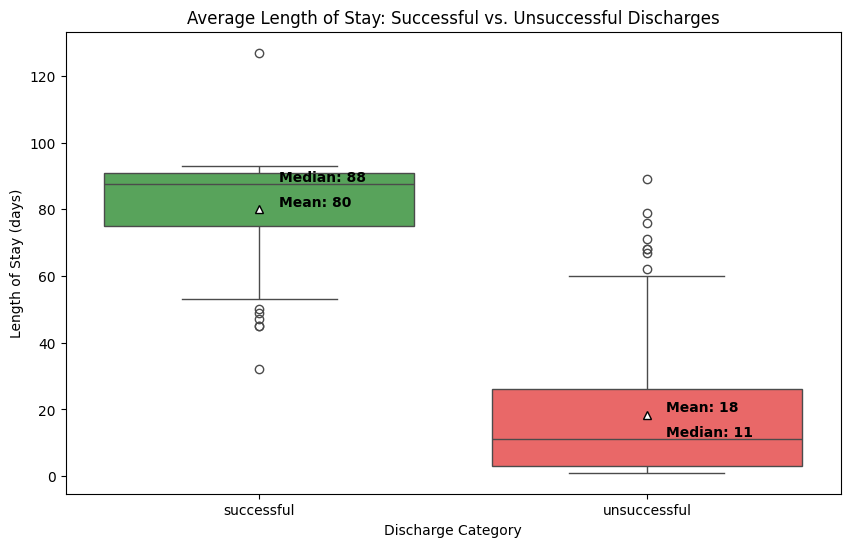

In [8]:
#average length of stay before for successful vs unsuccessful discharges
stats_df2 = los.groupby('Discharge_Cat')['Length_of_Stay'].agg(['mean', 'median'])

my_palette2 = ['#4CAF50', '#FF5252']

plt.figure(figsize=(10, 6))

ax = sns.boxplot(data=los, x='Discharge_Cat', y='Length_of_Stay', 
                 showmeans=True,
                 meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black"},
                 palette=my_palette2)

plt.title('Average Length of Stay: Successful vs. Unsuccessful Discharges')
plt.xlabel('Discharge Category')
plt.ylabel('Length of Stay (days)')

# Loop through each period to add the text labels
for i, type in enumerate(stats_df2.index):
    mean_val = stats_df2.loc[type, 'mean']
    median_val = stats_df2.loc[type, 'median']
    
    # Add Median text label (slightly offset to the right of the center line)
    ax.text(i + 0.05, median_val, f'Median: {median_val:.0f}', 
            color='black', weight='semibold', verticalalignment='bottom')
    
    # Add Mean text label (slightly offset to the right of the triangle marker)
    ax.text(i + 0.05, mean_val, f'Mean: {mean_val:.0f}', 
            color='black', weight='semibold', verticalalignment='bottom')

plt.show()

The overall average length of stay for successful discharges is 80, while the median length of stay is 88. There is a left skew in the length of stay distribution for successful discharge types. This is expected, as the Women's Treatment Center follows a 90 day treatment plan, however the actual length of stay for successful discharges is determined by the client's progress. Some may hit their goals early, and some may need more time to graduate. The left skew may be exaggerated by a treatment episode that lasted 127 days.

 Let's filter that outlier out to see how the mean and median changes:

In [9]:
los_filtered = los[los['Length_of_Stay'] <= 100]

stats_df3 = los_filtered.groupby('Discharge_Cat')['Length_of_Stay'].agg(['mean', 'median'])

print(stats_df3)

                    mean  median
Discharge_Cat                   
successful     79.405797    87.0
unsuccessful   18.410405    11.0


The mean and median length of stay for successful discharges decreased by 1 when the outlier was removed. This isn't a major difference, and keeping the outlier point in the analysis is appropriate in this case as this is a natural variation in length of treatment. 

For unsuccessful discharges, the mean (18 days) is greater than the median (11 days). This indicates a right skew for the distribution of unsuccessful discharges. This is an expected result as this category includes clients that left the program before completion.

### 3. Length of Stay by Period

Next, the distribution of length of stay is created for both periods and compared. 

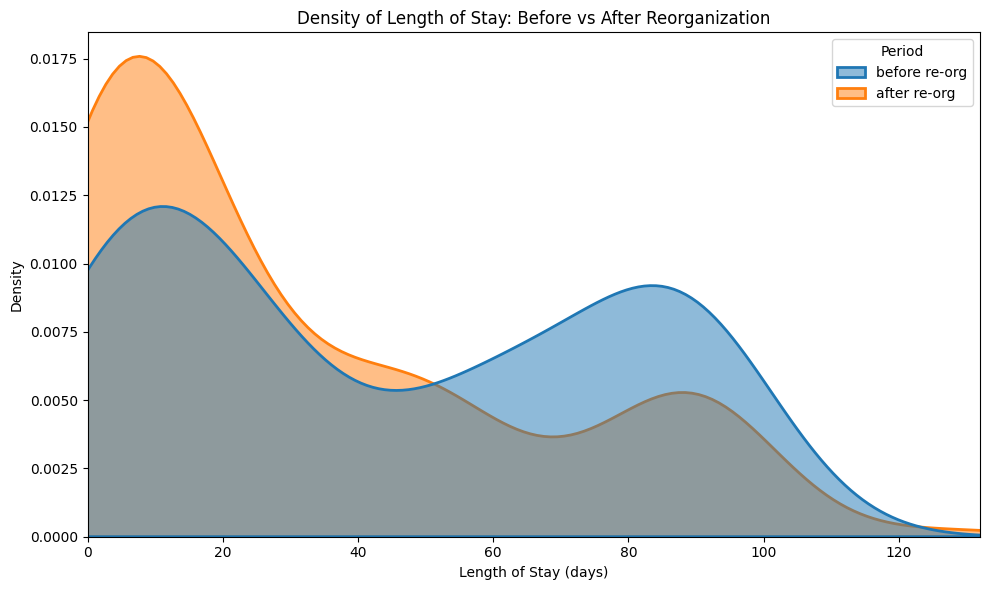

In [10]:
period_order = ['before re-org', 'after re-org']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=los, x='Length_of_Stay', hue='Period', 
            hue_order=period_order,
            fill=True, common_norm=False, alpha=0.5, linewidth=2)
plt.title('Density of Length of Stay: Before vs After Reorganization')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Density')
plt.xlim(0, los['Length_of_Stay'].max() + 5)
plt.tight_layout()
plt.show()

In the period before the reorganization, the distribution of length of stay is bimodal. Discharges are clustered around the the average lenth of stay for successful (88 days) and unsuccessful (18 days) discharge types. 

The 'after re-org' distribution is more unimodal, however there is a significant right skew. There were more discharges occuring eariler stage of treatment in the period after the re-organization compared to before. There are also less clients making to the later stage of treatment. 

Let's stratify the density plots to take a closer look at the length of stay by discharge type:

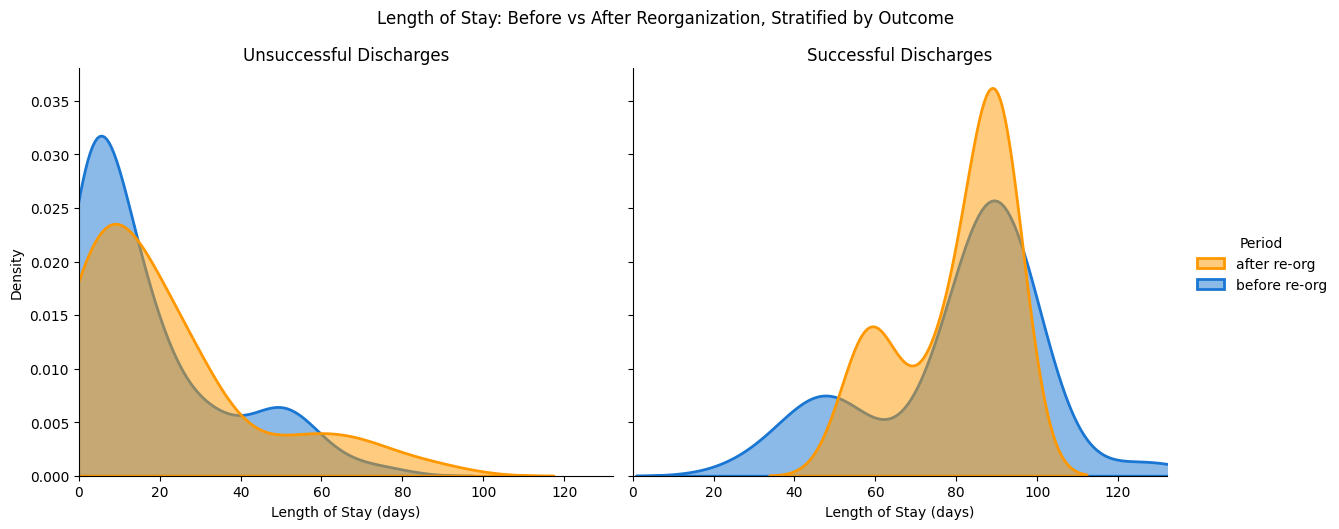

In [11]:
# faceted density plot

#define color mapping for the periods
custom_palette = {
    'before re-org': '#1976D2', 
    'after re-org': '#FF9800'
}

g = sns.displot(
    data=los, 
    x='Length_of_Stay', 
    hue='Period',            # Colors the lines by Before vs. After Re-org
    col='Discharge_Cat',    # Creates side-by-side charts for Successful vs. Unsuccessful
    col_order=['successful', 'unsuccessful'],
    palette=custom_palette,
    kind='kde',              # Density plot
    fill=True, 
    common_norm=False,       # Ensures each distribution is normalized independently
    alpha=0.5, 
    linewidth=2,
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Length of Stay (days)", "Density")

#g.set_titles("{col_name} Discharges") # Automatically titles them based on the column values
# Manually override the titles 
axes = g.axes.flatten()
axes[0].set_title("Unsuccessful Discharges")
axes[1].set_title("Successful Discharges")

g.fig.suptitle('Length of Stay: Before vs After Reorganization, Stratified by Outcome', y=1.05)
g.set(xlim=(0, los['Length_of_Stay'].max() + 5))

plt.show()

Unsuccessful discharges:
 - Both the 'before' and 'after' periods have a primary peak of discharges in the early days of treatment. In the after phase of the re-organization, the distribution is wider towards the later days of treatment. This indicates that there have been more unsuccessful discharges in the later stage of treatment for the period after the re-organizaton. 

Successful discharges:
 - Again, both primary peaks are centered around the overall median length of stay for successful discharges (88). The distribution for the 'after' period is more clustered around this point compared to the 'before' period. The distribution for the 'before' phase has a more gradual spread, indicating that there was more variability in the length of stay for successful discharges in this period.

